# Machine Learning Exploratory Data Analysis

## Import Libraries 

In [1]:
import pandas as pd 
import matplotlib.pyplot as plt
import seaborn as sns
import squarify
from sklearn.feature_selection import mutual_info_classif
from sklearn.preprocessing import LabelEncoder

## Import Data 

In [2]:
input_file = "data/processed_variants_for_EDA.tsv"

ml_data = pd.read_csv(input_file, sep='\t', low_memory=False)
print(f"Imported {len(ml_data):,} variants for EDA.")

Imported 1,906 variants for EDA.


## Initial Data Inspection 

In [3]:
print(f"The ML data has {ml_data.shape[0]} rows and {ml_data.shape[1]} columns.")

The ML data has 1906 rows and 18 columns.


In [4]:
print("The columns in the data set have the following data types:")
print(ml_data.dtypes)

The columns in the data set have the following data types:
Hugo_Symbol              str
Consequence              str
Variant_Type             str
MUTATION_EFFECT          str
gnomAD_AF            float64
has_gnomAD_AF           bool
Polyphen_Score       float64
SIFT_Score           float64
In_Hotspot              bool
IN_DOMAIN               bool
n_protein_domains      int64
IN_FUNC_SITE            bool
n_func_sites           int64
is_null_variant         bool
ncg_tsg                 bool
ncg_oncogene            bool
is_null_var_tsg         bool
ONCOGENIC                str
dtype: object


In [5]:
print("The five first rows of the df:")
display(ml_data.head())


The five first rows of the df:


,Hugo_Symbol,Consequence,Variant_Type,MUTATION_EFFECT,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,is_null_variant,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC
0,MAPK1,missense_variant,SNP,Likely Loss-of-function,0.000000,False,1.000,0.01,False,True,1,False,0,False,False,True,False,Likely Neutral
1,BRCA1,missense_variant,SNP,Loss-of-function,0.000000,False,0.344,0.00,False,False,0,False,0,False,True,False,False,Oncogenic
2,BRCA1,missense_variant,SNP,Loss-of-function,0.000032,True,0.026,0.00,False,True,1,False,0,False,True,False,False,Oncogenic
3,TP53,missense_variant,SNP,Loss-of-function,0.000000,False,0.396,0.12,True,True,1,True,2,False,True,True,False,Oncogenic
4,TP53,missense_variant,SNP,Likely Loss-of-function,0.000000,False,0.838,0.02,True,True,1,True,1,False,True,True,False,Oncogenic


In [6]:
print("The five last rows of the df:") 
display(ml_data.tail())

The five last rows of the df:


,Hugo_Symbol,Consequence,Variant_Type,MUTATION_EFFECT,gnomAD_AF,has_gnomAD_AF,Polyphen_Score,SIFT_Score,In_Hotspot,IN_DOMAIN,n_protein_domains,IN_FUNC_SITE,n_func_sites,is_null_variant,ncg_tsg,ncg_oncogene,is_null_var_tsg,ONCOGENIC
1901,BIRC3,missense_variant,SNP,Likely Neutral,0.0,False,0.223,0.03,False,True,1,False,0,False,True,True,False,Likely Neutral
1902,MED12,missense_variant,SNP,Likely Loss-of-function,0.0,False,0.178,0.01,False,False,0,False,0,False,True,False,False,Oncogenic
1903,MED12,missense_variant,SNP,Likely Loss-of-function,0.0,False,0.014,1.00,False,False,0,False,0,False,True,False,False,Oncogenic
1904,MED12,missense_variant,SNP,Likely Loss-of-function,0.0,False,0.974,0.00,False,False,0,False,0,False,True,False,False,Oncogenic
1905,MED12,missense_variant,SNP,Likely Loss-of-function,0.0,False,0.035,0.01,False,False,0,False,0,False,True,False,False,Oncogenic


In [7]:
print("Descriptive statistics on numeric columns in the df:")
print(ml_data.describe())

Descriptive statistics on numeric columns in the df:
         gnomAD_AF  Polyphen_Score   SIFT_Score  n_protein_domains  \
count  1906.000000     1510.000000  1510.000000        1906.000000   
mean      0.000004        0.689134     0.077132           0.634313   
std       0.000020        0.387168     0.176132           0.483923   
min       0.000000        0.000000     0.000000           0.000000   
25%       0.000000        0.323250     0.000000           0.000000   
50%       0.000000        0.935000     0.000000           1.000000   
75%       0.000000        0.998000     0.060000           1.000000   
max       0.000352        1.000000     1.000000           2.000000   

       n_func_sites  
count   1906.000000  
mean       0.552466  
std        0.591831  
min        0.000000  
25%        0.000000  
50%        1.000000  
75%        1.000000  
max        3.000000  


## Target Variable Analysis

In [8]:
print("Variants per target class:")
print(ml_data.groupby("ONCOGENIC").size())

Variants per target class:
ONCOGENIC
Likely Neutral     857
Oncogenic         1049
dtype: int64


In [9]:
oncogenic = ml_data[ml_data["ONCOGENIC"] == "Oncogenic"]
neutral = ml_data[ml_data["ONCOGENIC"] == "Likely Neutral"]
print(f"{len(oncogenic)/len(ml_data)*100:.2f}% of the variants are Oncogenic.")
print(f"{len(neutral)/len(ml_data)*100:.2f}% of the variants are Likely Neutral")

55.04% of the variants are Oncogenic.
44.96% of the variants are Likely Neutral


## Univariate Analysis 

### Numeric Feature Distributions

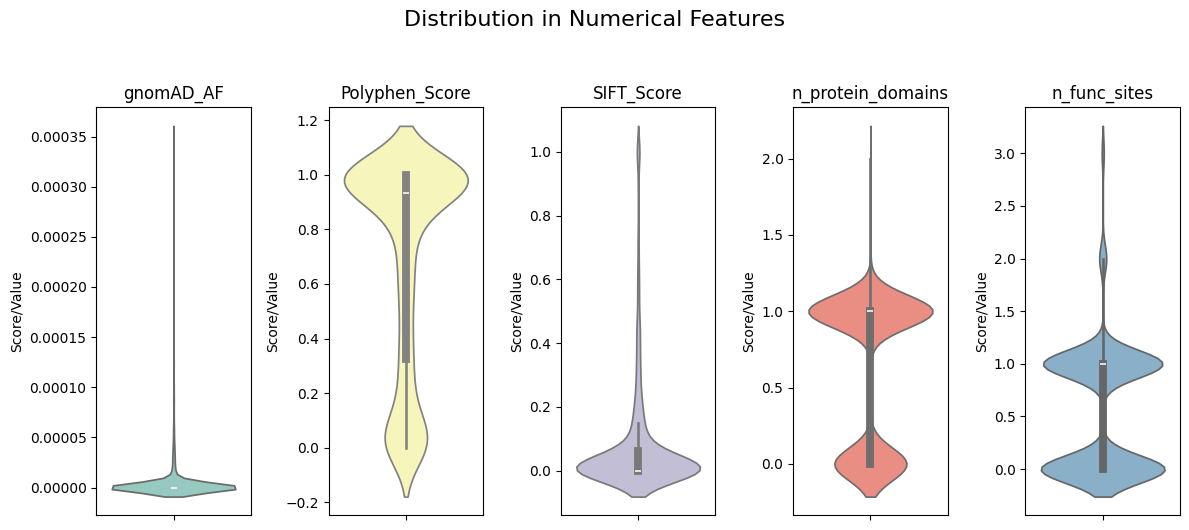

In [10]:
# define the numeric columns 
numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", "n_protein_domains", "n_func_sites"]

# define the subplots 
fig, axes = plt.subplots(1, len(numeric_cols), figsize=(12,5)) 

# Loop through columns and create violinplot
for i, col in enumerate(numeric_cols):
    sns.violinplot(y=ml_data[col], ax=axes[i], color=sns.color_palette('Set3')[i])
    
    # decorate plot
    axes[i].set_title(col, fontsize=12)
    axes[i].set_ylabel("Score/Value")
    axes[i].set_xlabel("") # remove x-label 

plt.suptitle("Distribution in Numerical Features", fontsize=16, y=1.05)

plt.tight_layout()
plt.savefig("plots/violinplot_numeric.png", dpi=300, bbox_inches='tight')
plt.show()


### Binary Feature Distributions

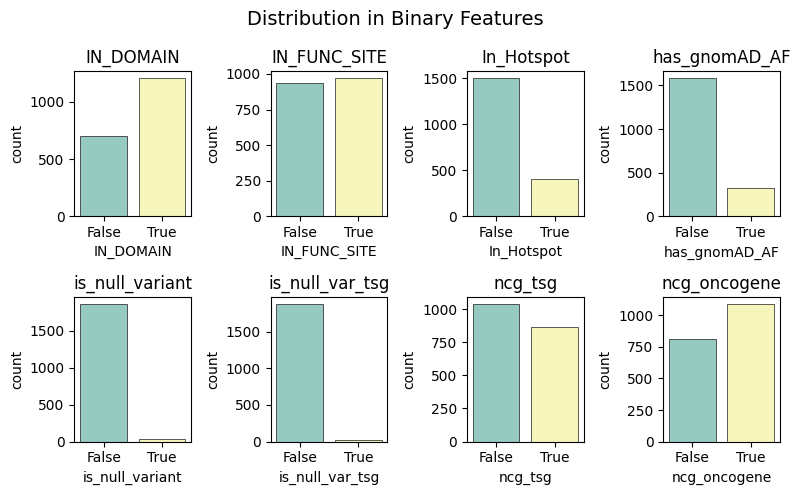

In [11]:
binary_cols = ["IN_DOMAIN", "IN_FUNC_SITE", "In_Hotspot", 
               "has_gnomAD_AF", "is_null_variant", "is_null_var_tsg", 
               "ncg_tsg", "ncg_oncogene"]

fig, axes = plt.subplots(2,4, figsize=(8,5))

axes = axes.flatten()

for i, col in enumerate(binary_cols):
    sns.countplot(x=col, data=ml_data, ax=axes[i], 
                  hue=col, palette="Set3", legend=False,
                  edgecolor="0.1", linewidth=0.5)
    axes[i].set_title(col)

plt.suptitle("Distribution in Binary Features", fontsize=14)

plt.tight_layout()
plt.savefig("plots/barplots_binary.png", dpi=300)
plt.show()

### Categorical Feature Distributions

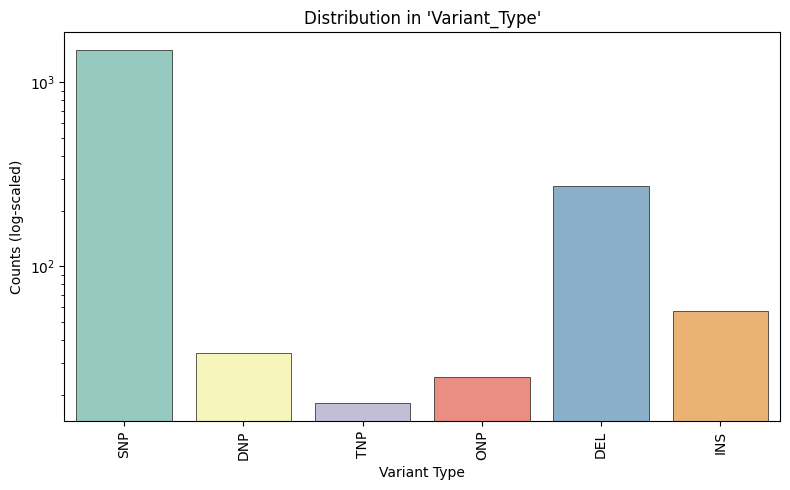

In [12]:
plt.figure(figsize=(8,5))

sns.countplot(data=ml_data, x="Variant_Type", hue="Variant_Type",
              palette="Set3", legend=False, edgecolor="0.1", linewidth=0.5)
plt.title("Distribution in 'Variant_Type'")
plt.xlabel("Variant Type")
plt.yscale("log")
plt.ylabel("Counts (log-scaled)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("plots/barplot_variant_type.png", dpi=300)
plt.show()


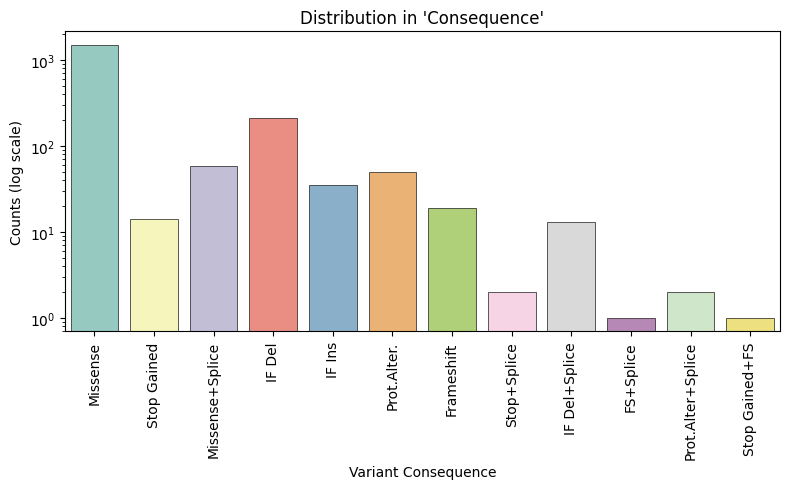

In [13]:
plt.figure(figsize=(8,5))

consequence_map = {
    "missense_variant"                          : "Missense",
    "stop_gained"                               : "Stop Gained",
    "inframe_deletion"                          : "IF Del",
    "inframe_insertion"                         : "IF Ins",
    "missense_variant,splice_region_variant"    : "Missense+Splice",
    "protein_altering_variant"                  : "Prot.Alter.",
    "frameshift_variant"                        : "Frameshift",
    "stop_gained,splice_region_variant"         : "Stop+Splice",
    "inframe_deletion,splice_region_variant"    : "IF Del+Splice",
    "frameshift_variant,splice_region_variant"  : "FS+Splice",
    "protein_altering_variant,splice_region_variant" : "Prot.Alter+Splice",
    "stop_gained,frameshift_variant"            : "Stop Gained+FS"
}

ml_data["Consequence_short"] = ml_data["Consequence"].map(consequence_map).fillna(ml_data["Consequence"])

sns.countplot(data=ml_data, x="Consequence_short", hue="Consequence_short",
              palette="Set3", legend=False, edgecolor="0.1", linewidth=0.5)
plt.title("Distribution in 'Consequence'")
plt.xlabel("Variant Consequence")
plt.yscale("log")
plt.ylabel("Counts (log scale)")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("plots/barplot_consequence.png", dpi=300)
plt.show()

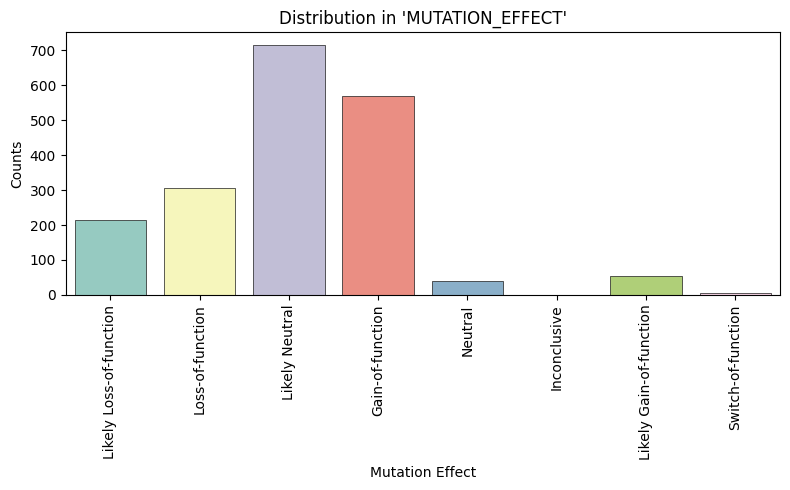

In [14]:
plt.figure(figsize=(8,5))

sns.countplot(data=ml_data, x="MUTATION_EFFECT", hue="MUTATION_EFFECT",
              palette="Set3", legend=False, edgecolor="0.1", linewidth=0.5)
plt.title("Distribution in 'MUTATION_EFFECT'")
plt.xlabel("Mutation Effect")
plt.ylabel("Counts")
plt.xticks(rotation=90)

plt.tight_layout()
plt.savefig("plots/barplot_mutation_effect.png", dpi=300)
plt.show()

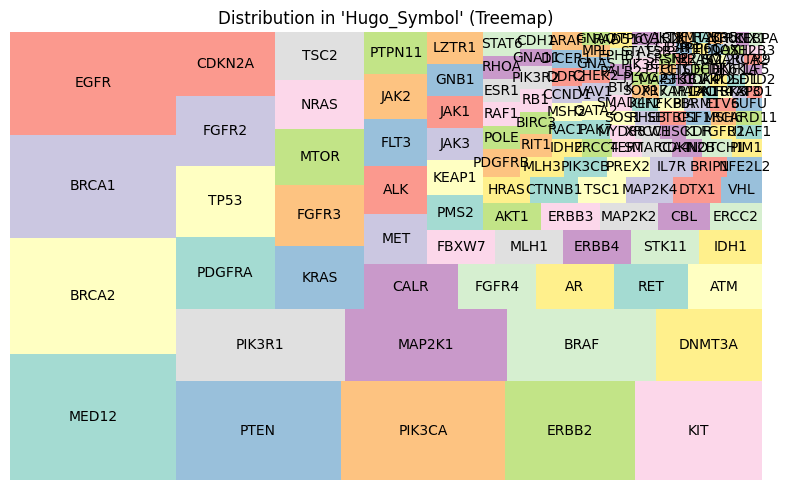

In [15]:
gene_counts = ml_data["Hugo_Symbol"].value_counts()

plt.figure(figsize=(8, 5))
squarify.plot(sizes=gene_counts.values,
              label=gene_counts.index,
              alpha=0.8, color=sns.color_palette("Set3", len(gene_counts)))
plt.title("Distribution in 'Hugo_Symbol' (Treemap)")
plt.axis("off")

plt.tight_layout()
plt.savefig("plots/treemap_genes.png", dpi=300)
plt.show()

## Multivariate Analysis

### Correlation Heatmap (numeric features)

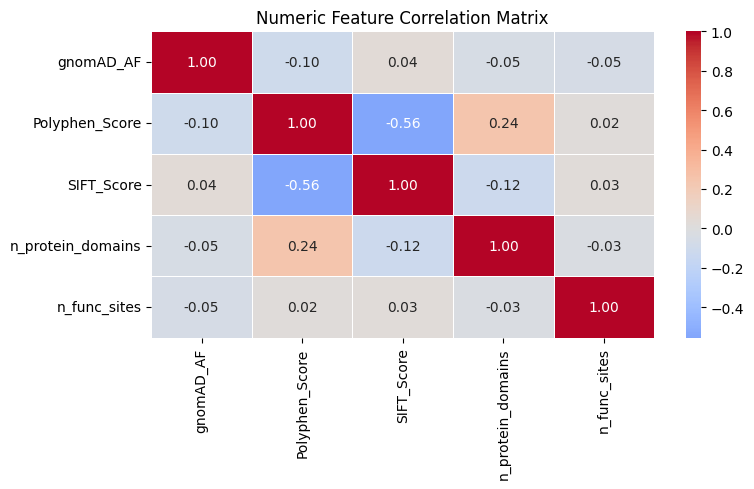

In [16]:
numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites"]

plt.figure(figsize=(8,5)) 
sns.heatmap(ml_data[numeric_cols].corr(),
            annot=True, fmt=".2f", cmap="coolwarm",
            center=0, edgecolor="white", linewidths=0.5)
plt.title("Numeric Feature Correlation Matrix")

plt.tight_layout() 
plt.savefig("plots/correlation_heatmap_numeric.png", dpi=300)
plt.show() 


Positive correlation: Polyphen_Score and n_protein_domains 

Negative correlation: SIFT_Score and Polyphen_Score, SIFT_Score and n_protein_domains

### Mutual Information (MI) analysis on binary columns

In [ ]:
numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites"]

# Prepare data 
le = LabelEncoder()
y = le.fit_transform(ml_data["ONCOGENIC"]) 
X_numeric = ml_data[numeric_cols]

# Calculate MI
mi_scores = mutual_info_classif(X_numeric, y, discrete_features=False, random_state=42)

# Create overview
mi_results_numeric = pd.DataFrame({'Feature': numeric_cols, 'MI Score': mi_scores})
mi_results_numeric = mi_results_numeric.sort_values(by='MI Score', ascending=False)

print(mi_results_numeric)


### Mutual Information (MI) analysis on binary columns 

In [ ]:
binary_cols = ["IN_DOMAIN", "IN_FUNC_SITE", "In_Hotspot", 
               "has_gnomAD_AF", "is_null_variant", "is_null_var_tsg",
               "ncg_tsg", "ncg_oncogene"]

# Prepare data 
le = LabelEncoder()
y = le.fit_transform(ml_data["ONCOGENIC"]) 
X_binary = ml_data[binary_cols].astype(int)

# Calculate MI
mi_scores = mutual_info_classif(X_binary, y, discrete_features=True, random_state=42)

# Create overview
mi_results_binary = pd.DataFrame({'Feature': binary_cols, 'MI Score': mi_scores})
mi_results_binary = mi_results_binary.sort_values(by='MI Score', ascending=False)

print(mi_results_binary)

           Feature  MI Score
2       In_Hotspot  0.070247
3    has_gnomAD_AF  0.035374
5  is_null_var_tsg  0.004616
7     ncg_oncogene  0.003281
6          ncg_tsg  0.002454
1     IN_FUNC_SITE  0.002261
0        IN_DOMAIN  0.001026
4  is_null_variant  0.000079


### Mutual Information Analysis on Categorical Features 

In [18]:
categorical_cols = ['Consequence_short', 'MUTATION_EFFECT', 'Variant_Type']

# Create copy of data 
mi_cat_data = ml_data[categorical_cols].copy()

# Encode each column 
le = LabelEncoder()
for col in categorical_cols:
    mi_cat_data[col] = le.fit_transform(mi_cat_data[col].astype(str))

# Calculate MI
y = le.fit_transform(ml_data["ONCOGENIC"])
mi_scores_cat = mutual_info_classif(mi_cat_data, y, discrete_features=True, random_state=42)

# Get results 
mi_cat_results = pd.DataFrame({'Feature': categorical_cols, 'MI Score': mi_scores_cat})
print(mi_cat_results.sort_values(by='MI Score', ascending=False))

             Feature  MI Score
1    MUTATION_EFFECT  0.566293
0  Consequence_short  0.047539
2       Variant_Type  0.040300


MUTATION_EFFECT should be removed from the model, since it provides much of the same information as the target variable. 

### Numeric Features vs. Target 

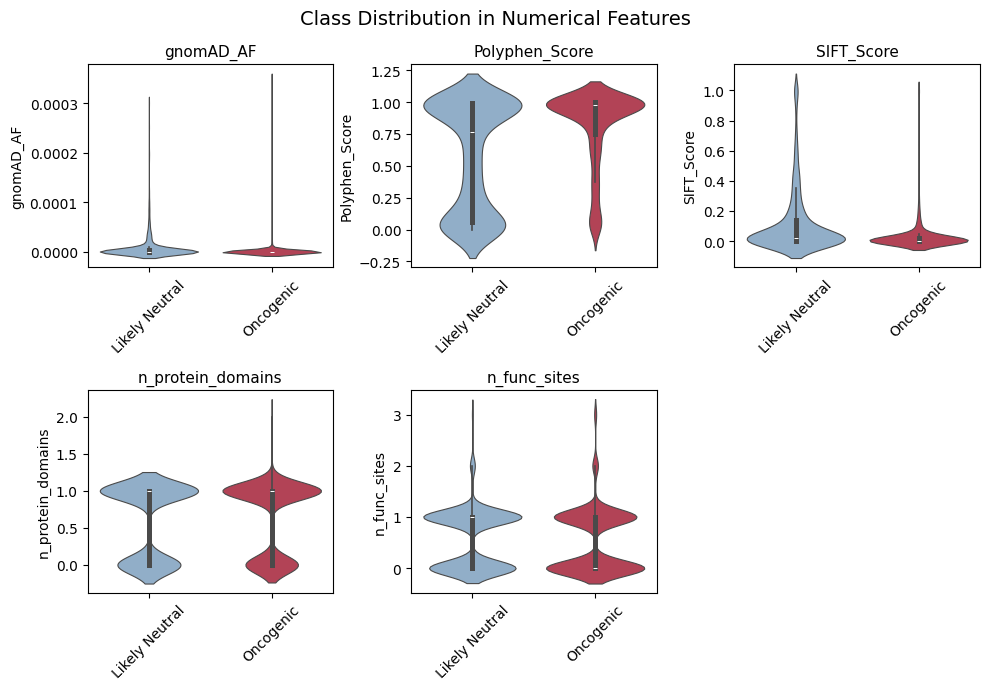

In [19]:
palette = {
    "Oncogenic"      : "#c4314a",
    "Likely Neutral" : "#88aed1",
}

fig, axes = plt.subplots(2,3, figsize=(10,7)) 
axes = axes.flatten() 

numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites"]

for i, col in enumerate(numeric_cols):
  sns.violinplot(data=ml_data, x="ONCOGENIC", y=col, 
              hue="ONCOGENIC", palette=palette,
              legend=False, ax=axes[i], 
              linewidth=0.8) 
  axes[i].set_title(col, fontsize=11) 
  axes[i].set_xlabel("") 
  axes[i].tick_params(axis="x", rotation=45) 

axes[-1].set_visible(False)

plt.suptitle("Class Distribution in Numerical Features", fontsize=14)

plt.tight_layout()
plt.savefig("plots/violinplots_classes.png", dpi=300)
plt.show() 


### Categorical and Binary Features vs. Target 

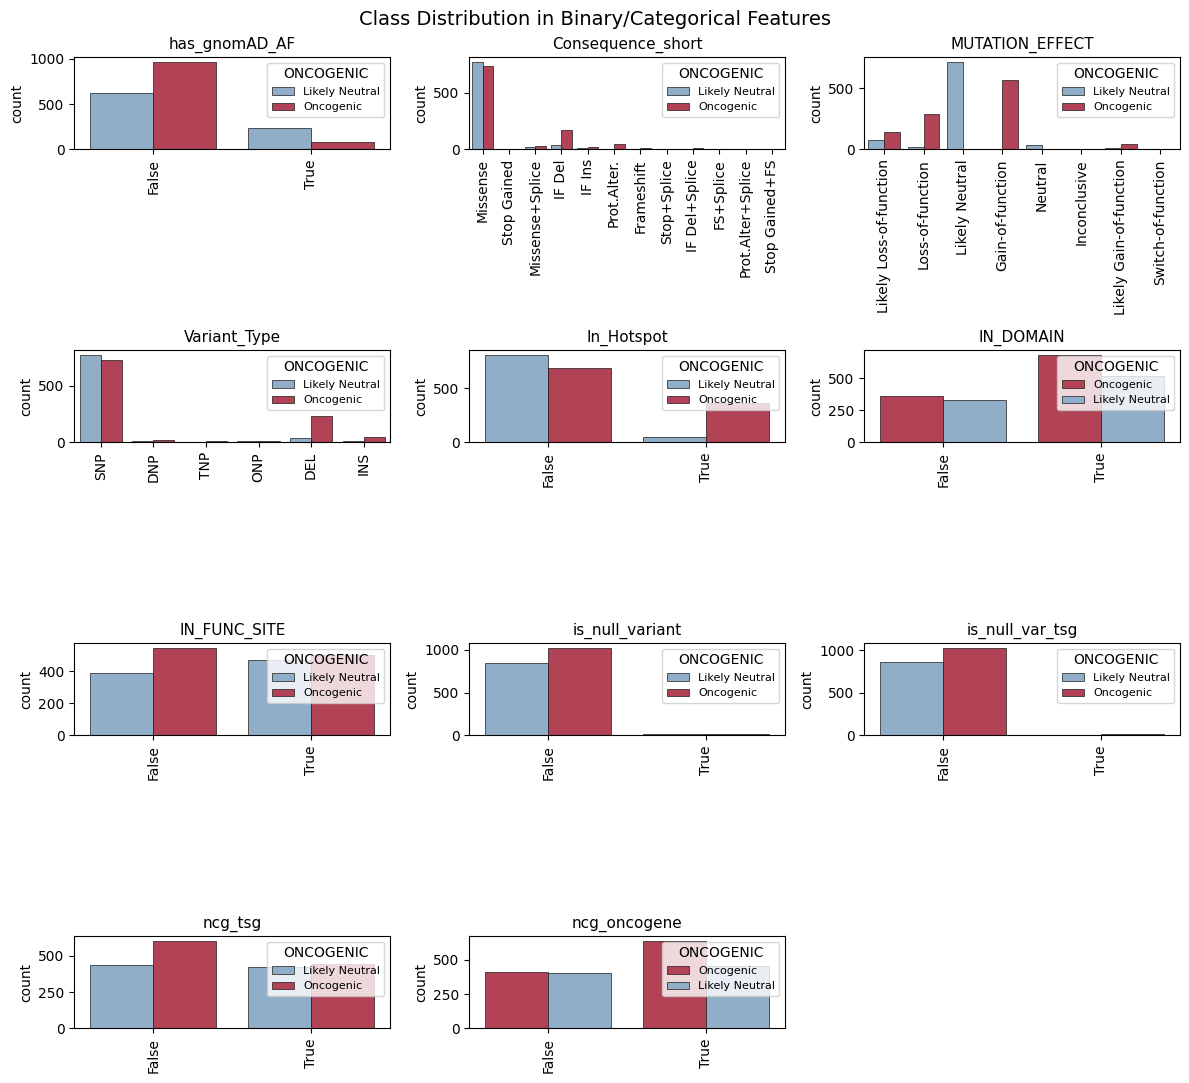

In [20]:
palette = {
    "Oncogenic"      : "#c4314a",
    "Likely Neutral" : "#88aed1",
}

categorical_cols = ['has_gnomAD_AF','Consequence_short', 'MUTATION_EFFECT', 
                    'Variant_Type', 'In_Hotspot','IN_DOMAIN', 
                    'IN_FUNC_SITE', 'is_null_variant', 'is_null_var_tsg',
                    'ncg_tsg', 'ncg_oncogene'
                    ]

fig, axes = plt.subplots(4,3, figsize=(12,11))
axes=axes.flatten()

for i, col in enumerate(categorical_cols): 
  sns.countplot(data=ml_data, x=col, hue="ONCOGENIC",
                palette=palette, ax=axes[i],
                edgecolor="0.1", linewidth=0.5) 
  axes[i].set_title(col, fontsize=11) 
  axes[i].set_xlabel("") 
  axes[i].tick_params(axis="x", rotation=90)
  axes[i].legend(title="ONCOGENIC", fontsize=8) 

for j in range(len(categorical_cols), len(axes)): 
  axes[j].set_visible(False) 

plt.suptitle("Class Distribution in Binary/Categorical Features", fontsize=14)

plt.tight_layout()
plt.savefig("plots/barplots_classes.png", dpi=300)
plt.show() 

### Pairplots (relationships between the numeric features) 

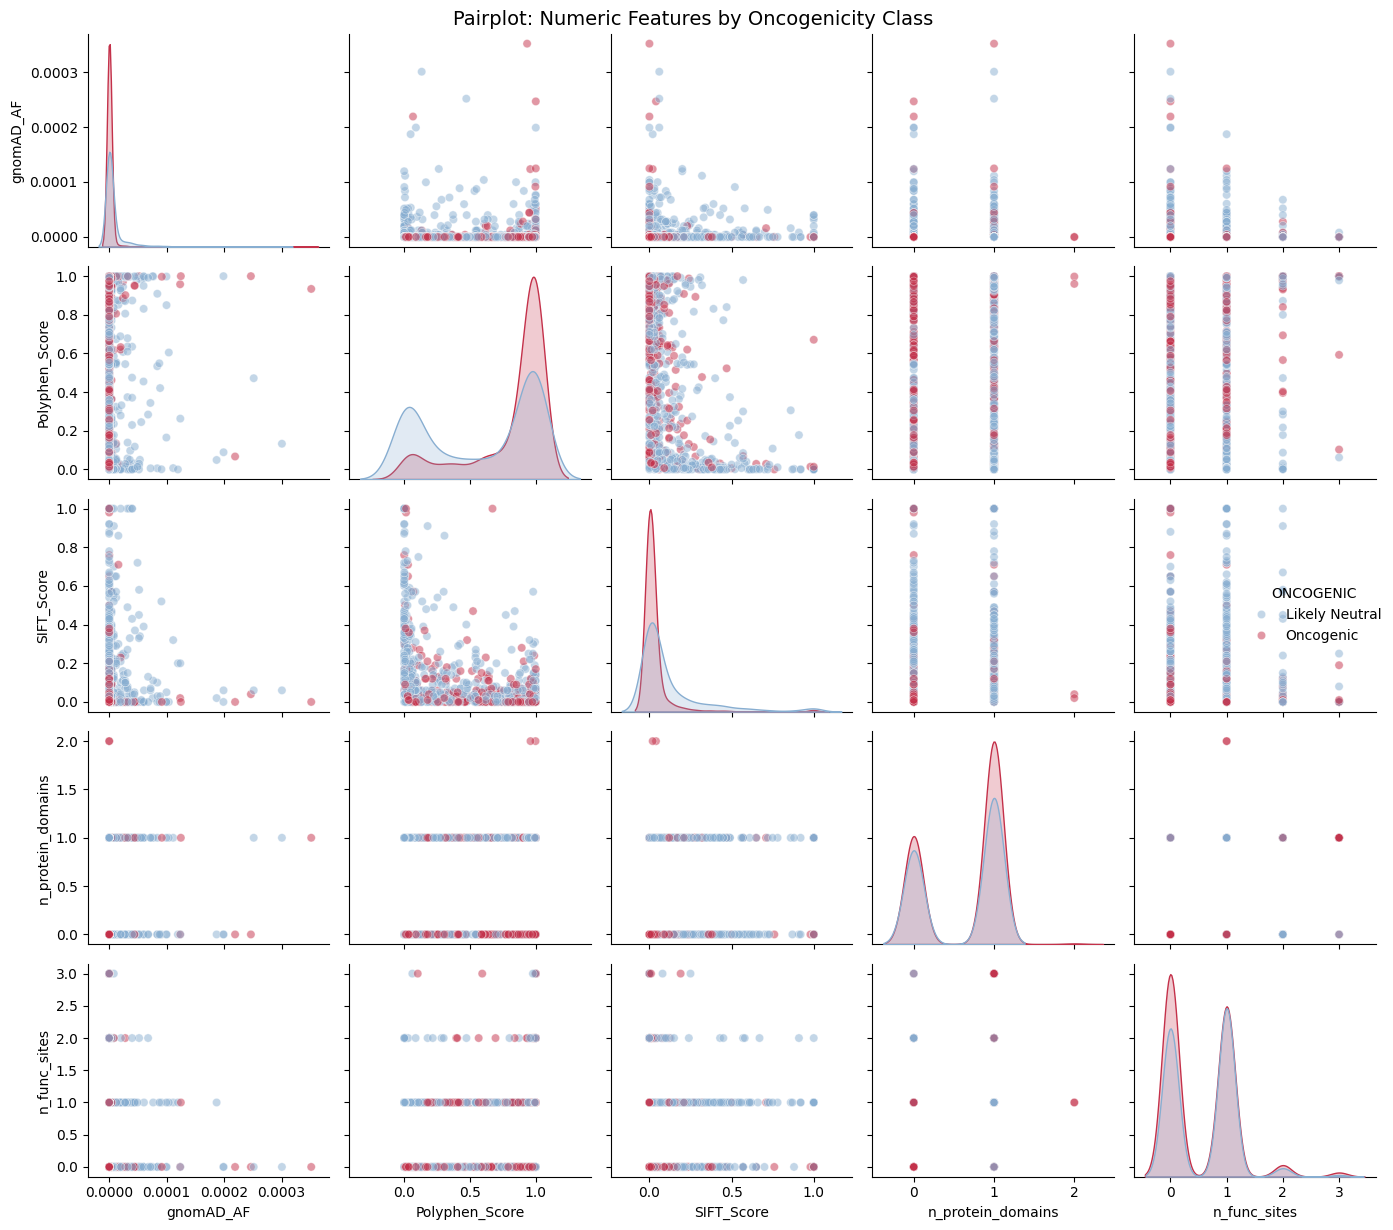

In [21]:
palette = {
    "Oncogenic"      : "#c4314a",
    "Likely Neutral" : "#88aed1",
}

numeric_cols = ["gnomAD_AF", "Polyphen_Score", "SIFT_Score", 
                "n_protein_domains", "n_func_sites", "ONCOGENIC"]

sns.pairplot(ml_data[numeric_cols], hue="ONCOGENIC", 
             palette=palette, plot_kws={"alpha":0.5},
             diag_kind="kde")
plt.suptitle("Pairplot: Numeric Features by Oncogenicity Class", fontsize=14)
plt.subplots_adjust(top=0.95) 

plt.tight_layout()
plt.savefig("plots/pairplot_classes.png", dpi=300)
plt.show()

### Top Genes per Oncogenic Class 

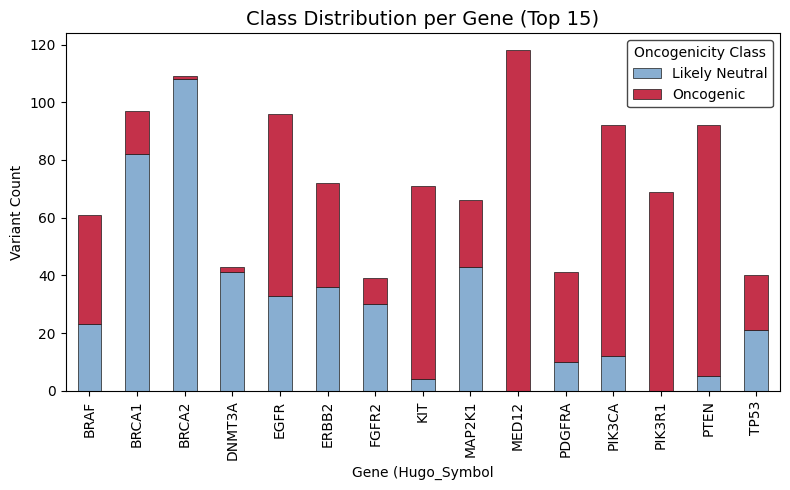

In [22]:
palette = {
    "Oncogenic"      : "#c4314a",
    "Likely Neutral" : "#88aed1",
}

top_genes = ml_data["Hugo_Symbol"].value_counts().nlargest(15).index
top_genes_df = ml_data[ml_data["Hugo_Symbol"].isin(top_genes)]

fig, ax = plt.subplots(figsize=(8, 5))
gene_class = top_genes_df.groupby(["Hugo_Symbol", "ONCOGENIC"]).size().unstack().fillna(0)

colors = [palette[col] for col in gene_class.columns]

gene_class.plot(kind="bar", stacked=True, color=colors,
                edgecolor="0.1", linewidth=0.5, ax=ax)

ax.set_title("Class Distribution per Gene (Top 15)", fontsize=14)
ax.set_xlabel("Gene (Hugo_Symbol") 
ax.set_ylabel("Variant Count")
ax.tick_params(axis="x", rotation=90)
ax.legend(title="Oncogenicity Class", edgecolor="0.1")

plt.tight_layout()
plt.savefig("plots/barplot_topgenes.png", dpi=300)
plt.show()